In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

In [23]:
X_train = pd.read_csv("splits/X_train.csv")
y_train = pd.read_csv("splits/y_train.csv").squeeze()

In [24]:
# Categorical Columns
categorical_cols = ['Company', 'TypeName', 'OpSys', 'CPU_Brand', 'GPU_Brand', 'Memory_Type']

# Preprocessing
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
], remainder='passthrough')


In [25]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2")
    
    results.append({
        "Model": name,
        "CV R² Mean": np.mean(scores),
        "CV R² Std": np.std(scores)
    })

results_df = pd.DataFrame(results)
print(results_df)

/root/miniforge3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/miniforge3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/miniforge3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/miniforge3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


               Model  CV R² Mean  CV R² Std
0  Linear Regression    0.801494   0.026795
1   Ridge Regression    0.804632   0.030585
2   Lasso Regression    0.528124   0.036042


/root/miniforge3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/root/miniforge3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/tmp/ipykernel_85812/2284639394.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='CV R² Mean', data=results_df, palette='viridis')


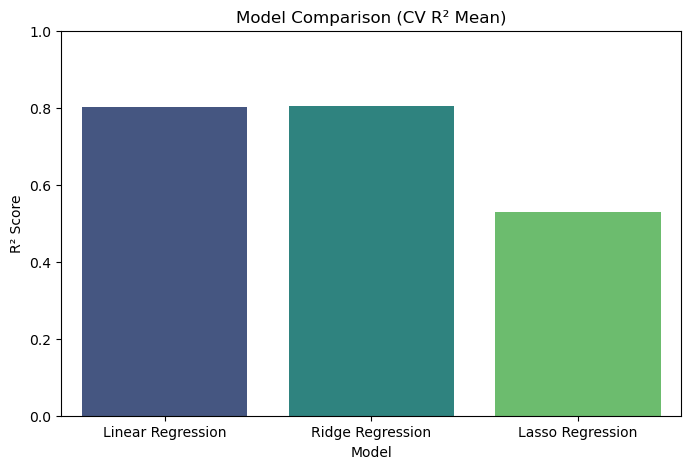

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='CV R² Mean', data=results_df, palette='viridis')
plt.title("Model Comparison (CV R² Mean)")
plt.ylim(0, 1)
plt.ylabel("R² Score")
plt.show()

In [27]:
results_df.to_csv("model_comparison_validation.csv", index=False)